DTC (1) = 0.67 accuracy
KNN (1) = 1.00 accuracy

Decision Tree Classifier results (varying max_depth):
max_depth = 1 -> Accuracy = 0.60
max_depth = 2 -> Accuracy = 1.00
max_depth = 3 -> Accuracy = 1.00
max_depth = 4 -> Accuracy = 1.00
max_depth = 5 -> Accuracy = 1.00
max_depth = 6 -> Accuracy = 1.00
max_depth = 7 -> Accuracy = 1.00
max_depth = 8 -> Accuracy = 1.00
max_depth = 9 -> Accuracy = 1.00
max_depth = 10 -> Accuracy = 1.00

K-Nearest Neighbors results (varying k):
k = 1 -> Accuracy = 1.00
k = 2 -> Accuracy = 1.00
k = 3 -> Accuracy = 1.00
k = 4 -> Accuracy = 1.00
k = 5 -> Accuracy = 1.00
k = 6 -> Accuracy = 1.00
k = 7 -> Accuracy = 0.93
k = 8 -> Accuracy = 1.00
k = 9 -> Accuracy = 1.00
k = 10 -> Accuracy = 1.00


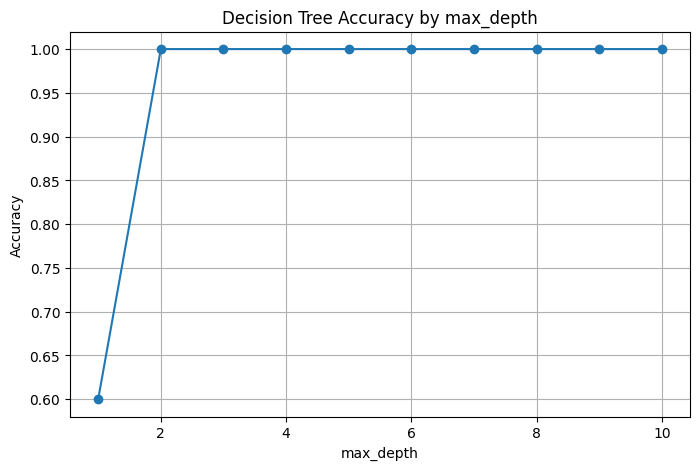

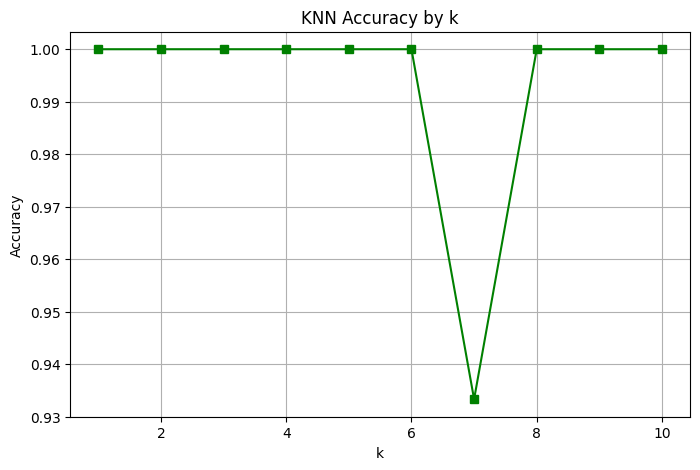


KNN classifier results using different feature combinations:
Features (0,) -> Accuracy = 0.60
Features (1,) -> Accuracy = 0.33
Features (2,) -> Accuracy = 0.93
Features (3,) -> Accuracy = 1.00
Features (0, 1) -> Accuracy = 0.87
Features (0, 2) -> Accuracy = 0.93
Features (0, 3) -> Accuracy = 1.00
Features (1, 2) -> Accuracy = 0.93
Features (1, 3) -> Accuracy = 1.00
Features (2, 3) -> Accuracy = 1.00
Features (0, 1, 2) -> Accuracy = 0.93
Features (0, 1, 3) -> Accuracy = 1.00
Features (0, 2, 3) -> Accuracy = 1.00
Features (1, 2, 3) -> Accuracy = 0.93
Features (0, 1, 2, 3) -> Accuracy = 1.00


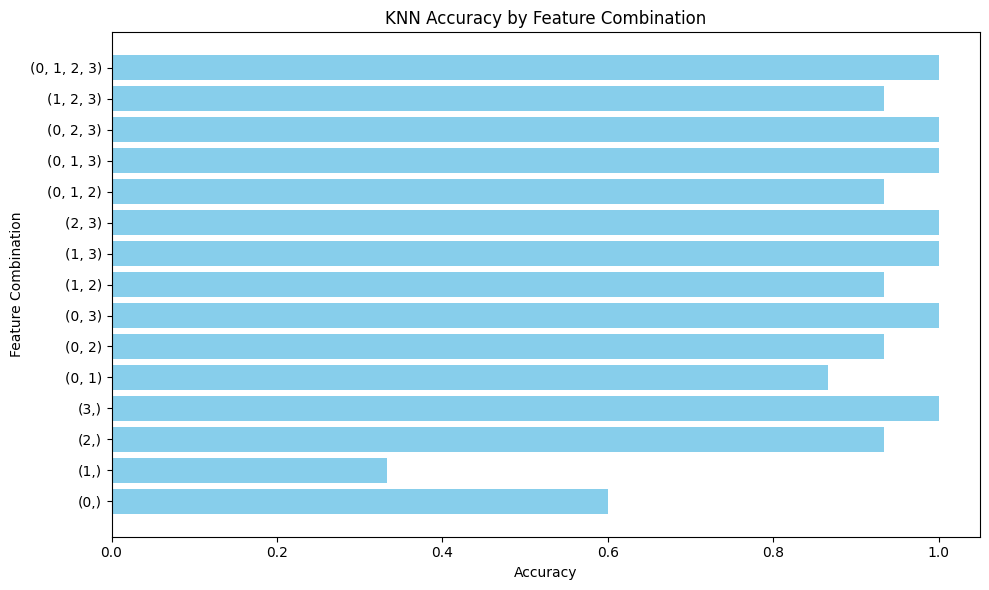


Decision Tree Classifier results with varying training sizes:
Training Size = 10% -> Accuracy = 0.81
Training Size = 20% -> Accuracy = 0.93
Training Size = 30% -> Accuracy = 0.92
Training Size = 40% -> Accuracy = 0.98
Training Size = 50% -> Accuracy = 1.00
Training Size = 60% -> Accuracy = 0.98
Training Size = 70% -> Accuracy = 1.00
Training Size = 80% -> Accuracy = 1.00
Training Size = 90% -> Accuracy = 1.00


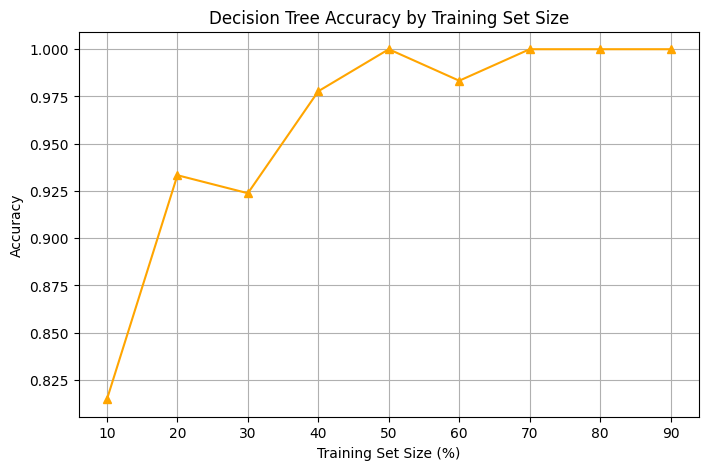

In [ ]:
#Problems Resolution below: 

# PE07- Iris Dataset Analysis with Visualizations

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import itertools

# Load Iris data
iris = datasets.load_iris()
x = iris.data
y = iris.target

# --------------------------------------------------------------------------------------------------------
# Problem 1 – Varying Parameters

print("DTC (1) = %.2f accuracy" % accuracy_score(y, DecisionTreeClassifier(max_depth=1).fit(x, y).predict(x)))
print("KNN (1) = %.2f accuracy" % accuracy_score(y, KNeighborsClassifier(n_neighbors=1).fit(x, y).predict(x)))

# Use consistent training/testing split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

print("\nDecision Tree Classifier results (varying max_depth):")
dt_scores = []
for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)
    acc = accuracy_score(y_test, model.predict(x_test))
    dt_scores.append(acc)
    print(f"max_depth = {depth} -> Accuracy = {acc:.2f}")

print("\nK-Nearest Neighbors results (varying k):")
knn_scores = []
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    acc = accuracy_score(y_test, model.predict(x_test))
    knn_scores.append(acc)
    print(f"k = {k} -> Accuracy = {acc:.2f}")

# Plot Problem 1 results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), dt_scores, marker='o')
plt.title("Decision Tree Accuracy by max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), knn_scores, marker='s', color='green')
plt.title("KNN Accuracy by k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ----------------------------------------------------------------------------------------------------------------------
# Problem 2 – Feature Combinations

features = [0, 1, 2, 3]
combinations = []
for r in range(1, 5):
    combinations.extend(itertools.combinations(features, r))

feature_labels = []
combo_scores = []

print("\nKNN classifier results using different feature combinations:")
for combo in combinations:
    x_subset = x[:, combo]
    x_train, x_test, y_train, y_test = train_test_split(x_subset, y, test_size=0.1, random_state=42)
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(x_train, y_train)
    acc = accuracy_score(y_test, model.predict(x_test))
    feature_labels.append(str(combo))
    combo_scores.append(acc)
    print(f"Features {combo} -> Accuracy = {acc:.2f}")

# Plot Problem 2 results
plt.figure(figsize=(10, 6))
plt.barh(feature_labels, combo_scores, color='skyblue')
plt.title("KNN Accuracy by Feature Combination")
plt.xlabel("Accuracy")
plt.ylabel("Feature Combination")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------------------------------------------
# Problem 3 – Training Size Effect

train_sizes = []
accuracies = []

print("\nDecision Tree Classifier results with varying training sizes:")
for percent in range(1, 10):
    train_size = percent / 10
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=train_size, random_state=42)
    model = DecisionTreeClassifier(max_depth=3)
    model.fit(x_train, y_train)
    acc = accuracy_score(y_test, model.predict(x_test))
    train_sizes.append(int(train_size * 100))
    accuracies.append(acc)
    print(f"Training Size = {int(train_size * 100)}% -> Accuracy = {acc:.2f}")

# Plot Problem 3 results
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, accuracies, marker='^', color='orange')
plt.title("Decision Tree Accuracy by Training Set Size")
plt.xlabel("Training Set Size (%)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## Overview Summary 

This analysis focused on the Iris dataset using Decision Tree and KNN classifiers.

**Problem 1**: We tested different values for `max_depth` and `k`. Both models hit 100% accuracy, though Decision Tree showed overfitting with higher depth.
**Problem 2**: We explored all feature combinations. Petal width alone performed best.
**Problem 3**: We measured accuracy as training size increased. With 70%-90% training data, accuracy reached 100%.

Each problem included a supporting graph to visualize performance trends.
